In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT / "src"))
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "main_with_exo_2.csv"
TARGET = "GBP-CNY"

In [5]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from fx_forecasting.data.build_interim_dataset import build_interim_dataset, save_interim_dataset
from fx_forecasting.data.preprocess_sequence import prepare_sequences_from_csv
from fx_forecasting.data.inspect import inspect_data

## Data Loading and Preprocessing

In [ ]:
# Load raw data
raw_path = PROJECT_ROOT / "data" / "raw" / "fx_merged.csv"
df_raw = pd.read_csv(raw_path)

df_raw.head()

,Date,GBP-CNY,GBP-USD,GBP-EUR,GBP-JPY,GBP-KRW,GBP-CHF,ftse100_Close,gold_price,DTWEXBGS,DGS10,DCOILBRENTEU,vix_daily_close,glc_nominal_2,glc_nominal_10,ois_1,ois_2
0,2025/12/31,9.3889,1.3451,1.1454,210.8377,1941.0667,1.0657,9931.400391,3240.910,119.7456,4.18,61.35,14.95,3.63,4.57,3.49,3.45
1,2025/12/30,9.4219,1.3473,1.1457,210.6167,1941.3313,1.0654,9940.700195,3240.910,119.4939,4.14,62.30,14.33,3.65,4.58,3.49,3.46
2,2025/12/29,9.4431,1.3500,1.1472,210.5055,1937.0880,1.0656,9866.500000,3212.890,119.5899,4.12,63.10,14.20,3.65,4.58,3.50,3.47
3,2025/12/24,9.4675,1.3507,1.1468,210.4671,1954.4880,1.0655,9870.700195,3256.505,119.4372,4.15,63.70,13.47,3.67,4.60,3.51,3.50
4,2025/12/23,9.4628,1.3484,1.1451,210.8752,1999.7514,1.0650,9889.200195,3300.120,119.7057,4.18,63.70,14.00,3.67,4.59,3.51,3.50


In [4]:
# Build and save the interim dataset

interim_df, target_col, feature_cols = build_interim_dataset(
    df=df_raw,
    target_base_col="GBP-USD",
    timestamp_col="Date",
    horizon=1,
    target_type="return",
    return_lags=(1, 2, 3, 5, 10),
    rolling_windows=(5, 20, 60),
    include_calendar=True,
)

interim_path = PROJECT_ROOT / "data" / "interim" / "fx_interim.csv"
save_interim_dataset(interim_df, interim_path)

print("Saved to:", interim_path)
print("Shape:", interim_df.shape)
print("Target:", target_col)
print("Num features:", len(feature_cols))

Saved to: /Users/apple/COMP0197-group-project/data/interim/fx_interim.csv
Shape: (2717, 226)
Target: GBP-USD_ret_fwd1
Num features: 224


Shape: (2717, 226)

Columns:
['Date', 'glc_curve_slope', 'ois_slope', 'GBP-CNY_ret', 'GBP-USD_ret', 'GBP-EUR_ret', 'GBP-JPY_ret', 'GBP-KRW_ret', 'GBP-CHF_ret', 'ftse100_Close_ret', 'gold_price_ret', 'DTWEXBGS_ret', 'DCOILBRENTEU_ret', 'vix_daily_close_ret', 'DGS10_diff', 'glc_nominal_2_diff', 'glc_nominal_10_diff', 'ois_1_diff', 'ois_2_diff', 'glc_curve_slope_diff', 'ois_slope_diff', 'GBP-CNY_ret_lag1', 'GBP-CNY_ret_lag2', 'GBP-CNY_ret_lag3', 'GBP-CNY_ret_lag5', 'GBP-CNY_ret_lag10', 'GBP-USD_ret_lag1', 'GBP-USD_ret_lag2', 'GBP-USD_ret_lag3', 'GBP-USD_ret_lag5', 'GBP-USD_ret_lag10', 'GBP-EUR_ret_lag1', 'GBP-EUR_ret_lag2', 'GBP-EUR_ret_lag3', 'GBP-EUR_ret_lag5', 'GBP-EUR_ret_lag10', 'GBP-JPY_ret_lag1', 'GBP-JPY_ret_lag2', 'GBP-JPY_ret_lag3', 'GBP-JPY_ret_lag5', 'GBP-JPY_ret_lag10', 'GBP-KRW_ret_lag1', 'GBP-KRW_ret_lag2', 'GBP-KRW_ret_lag3', 'GBP-KRW_ret_lag5', 'GBP-KRW_ret_lag10', 'GBP-CHF_ret_lag1', 'GBP-CHF_ret_lag2', 'GBP-CHF_ret_lag3', 'GBP-CHF_ret_lag5', 'GBP-CHF_ret_lag10', 'ftse10

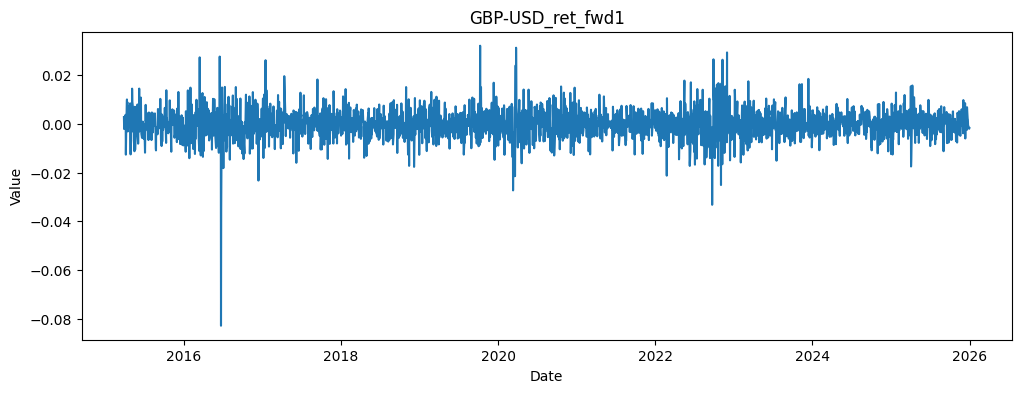

In [8]:
# Inspect the interim data
inspect_data(interim_df)

plt.figure(figsize=(12, 4))
plt.plot(pd.to_datetime(interim_df["Date"]), interim_df[target_col])
plt.title(target_col)
plt.xlabel("Date")
plt.ylabel("Value")
plt.show()

In [10]:
# Prepare train/test/windows from the saved CSV

results = prepare_sequences_from_csv(
    csv_path=interim_path,
    target_col=target_col,
    timestamp_col="Date",
    test_ratio=0.2,
    scale_features=True,
    scale_target=False,
    scaler_type="standard",
    lookback=30,
    train_csv_path=PROJECT_ROOT / "data" / "processed" / "train_scaled.csv",
    test_csv_path=PROJECT_ROOT / "data" / "processed" / "test_scaled.csv",
)

X_train = results["X_train"]
y_train = results["y_train"]
X_test = results["X_test"]
y_test = results["y_test"]

train_df = results["train_df"]
test_df = results["test_df"]
feature_cols = results["feature_cols"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)



X_train: (2143, 30, 224)
y_train: (2143,)
X_test : (544, 30, 224)
y_test : (544,)


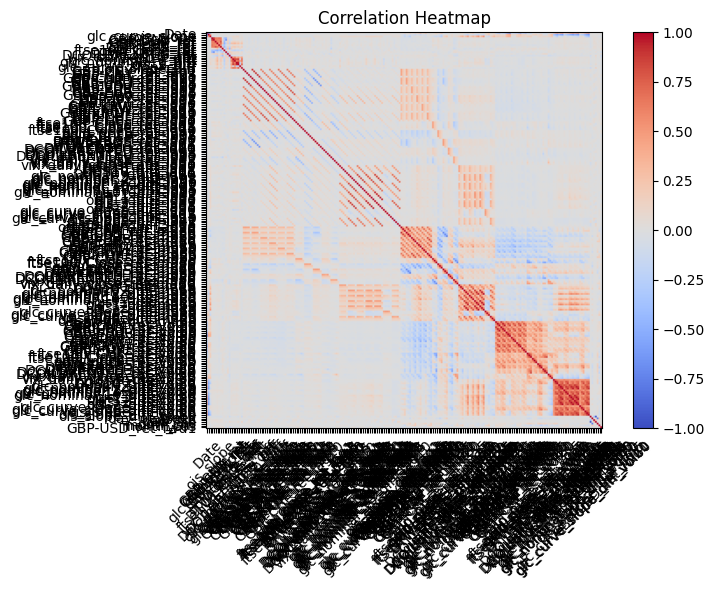

/Users/apple/COMP0197-group-project/src/fx_forecasting/visualization/plots.py:22: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


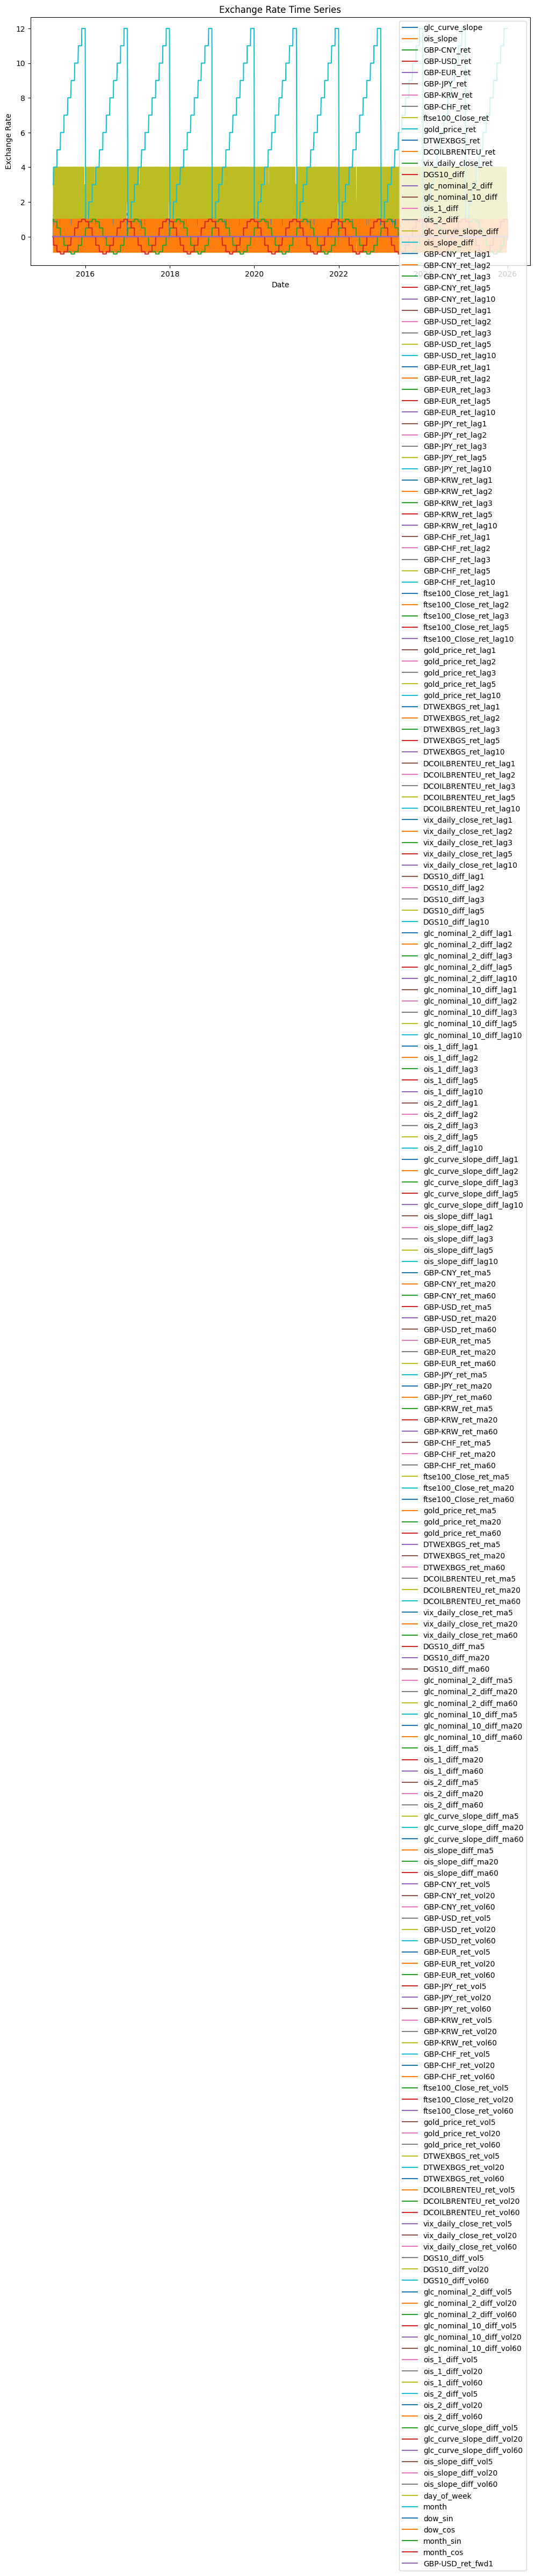

NameError: name 'TARGET' is not defined

In [ ]:
# visualisations

from fx_forecasting.visualization.plots import (
    plot_all_series,
    plot_target_series,
    plot_histogram,
    plot_boxplot,
    plot_correlation_heatmap
)

plot_correlation_heatmap(interim_df)
plot_all_series(interim_df, timestamp_col='Date')
plot_target_series(interim_df, TARGET, timestamp_col='Date')
plot_histogram(interim_df, TARGET)
plot_boxplot(interim_df, cols=feature_cols[:3])

## Model Training

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# Hyperparameters
HIDDEN_DIM = 64
NUM_LAYERS = 2
LR = 0.001
EPOCHS = 50
BATCH_SIZE = 64


In [ ]:
# Data loaders
from torch.utils.data import TensorDataset, DataLoader

# convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# datasets
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_test_t, y_test_t)

# dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
from fx_forecasting.models.baseline import DeterministicLSTM
from fx_forecasting.training.train import train_model


model = DeterministicLSTM(
    input_dim=X_train.shape[-1],
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS
)

# Optimizer and loss
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss() 
device = "cuda" if torch.cuda.is_available() else "cpu"

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=EPOCHS,
    device=device,
    save_path="best_baseline_model.pt",
    early_stopping_patience=5
)

Epoch 1/50 [Val]: 100%|██████████| 9/9 [00:00<00:00, 191.87it/s]


Epoch 1/50 | Train Loss: 0.4864 | Val Loss: 0.1589 | Train MAE: 0.5093 | Val MAE: 0.2874 | Train RMSE: 0.6632 | Val RMSE: 0.3251
Saved best model at epoch 1 with val loss 0.1589


Epoch 2/50 [Val]: 100%|██████████| 9/9 [00:00<00:00, 176.70it/s]


Epoch 2/50 | Train Loss: 0.0612 | Val Loss: 0.0832 | Train MAE: 0.1829 | Val MAE: 0.2328 | Train RMSE: 0.2416 | Val RMSE: 0.2609
Saved best model at epoch 2 with val loss 0.0832


Epoch 3/50 [Val]: 100%|██████████| 9/9 [00:00<00:00, 165.76it/s]


...

Epoch 23/50 | Train Loss: 0.0186 | Val Loss: 0.0342 | Train MAE: 0.1019 | Val MAE: 0.1403 | Train RMSE: 0.1347 | Val RMSE: 0.1663


Epoch 24/50 [Val]: 100%|██████████| 9/9 [00:00<00:00, 201.23it/s]


Epoch 24/50 | Train Loss: 0.0181 | Val Loss: 0.0305 | Train MAE: 0.1000 | Val MAE: 0.1318 | Train RMSE: 0.1325 | Val RMSE: 0.1576


Epoch 25/50 [Val]: 100%|██████████| 9/9 [00:00<00:00, 211.72it/s]

Epoch 25/50 | Train Loss: 0.0182 | Val Loss: 0.0321 | Train MAE: 0.1008 | Val MAE: 0.1319 | Train RMSE: 0.1323 | Val RMSE: 0.1568
Early stopping at epoch 25
Best model was from epoch 20 with val loss 0.0286


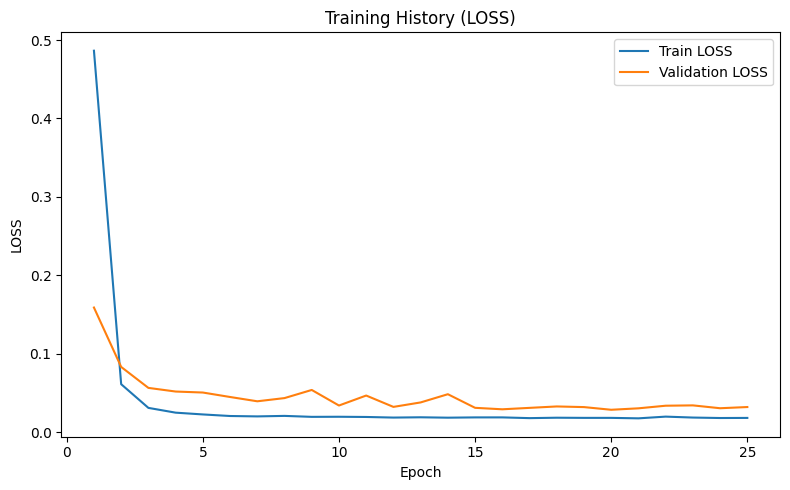

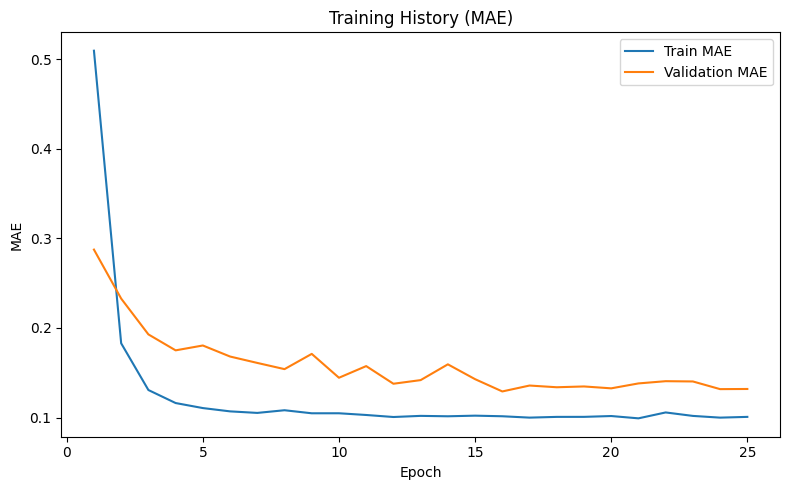

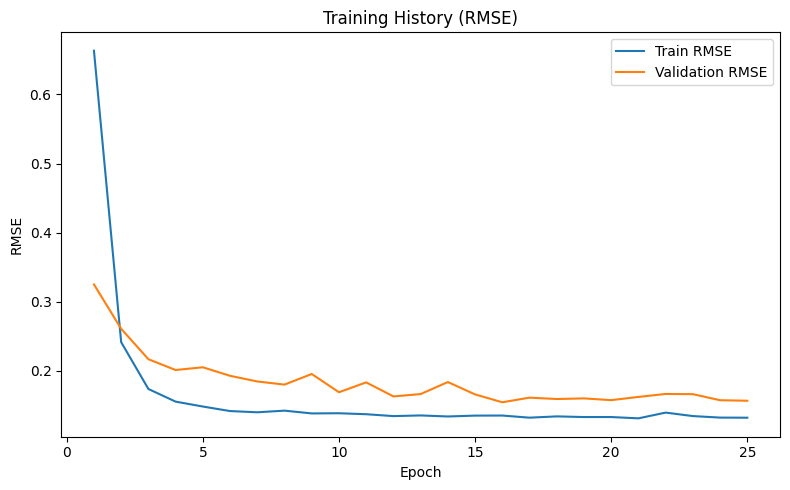

In [ ]:
from fx_forecasting.visualization.plots import plot_training_history

plot_training_history(history, metric="loss")
plot_training_history(history, metric="mae")
plot_training_history(history, metric="rmse")

## Evaluation 


Evaluation metrics:
MSE: 0.034043
RMSE: 0.184508
MAE: 0.136239


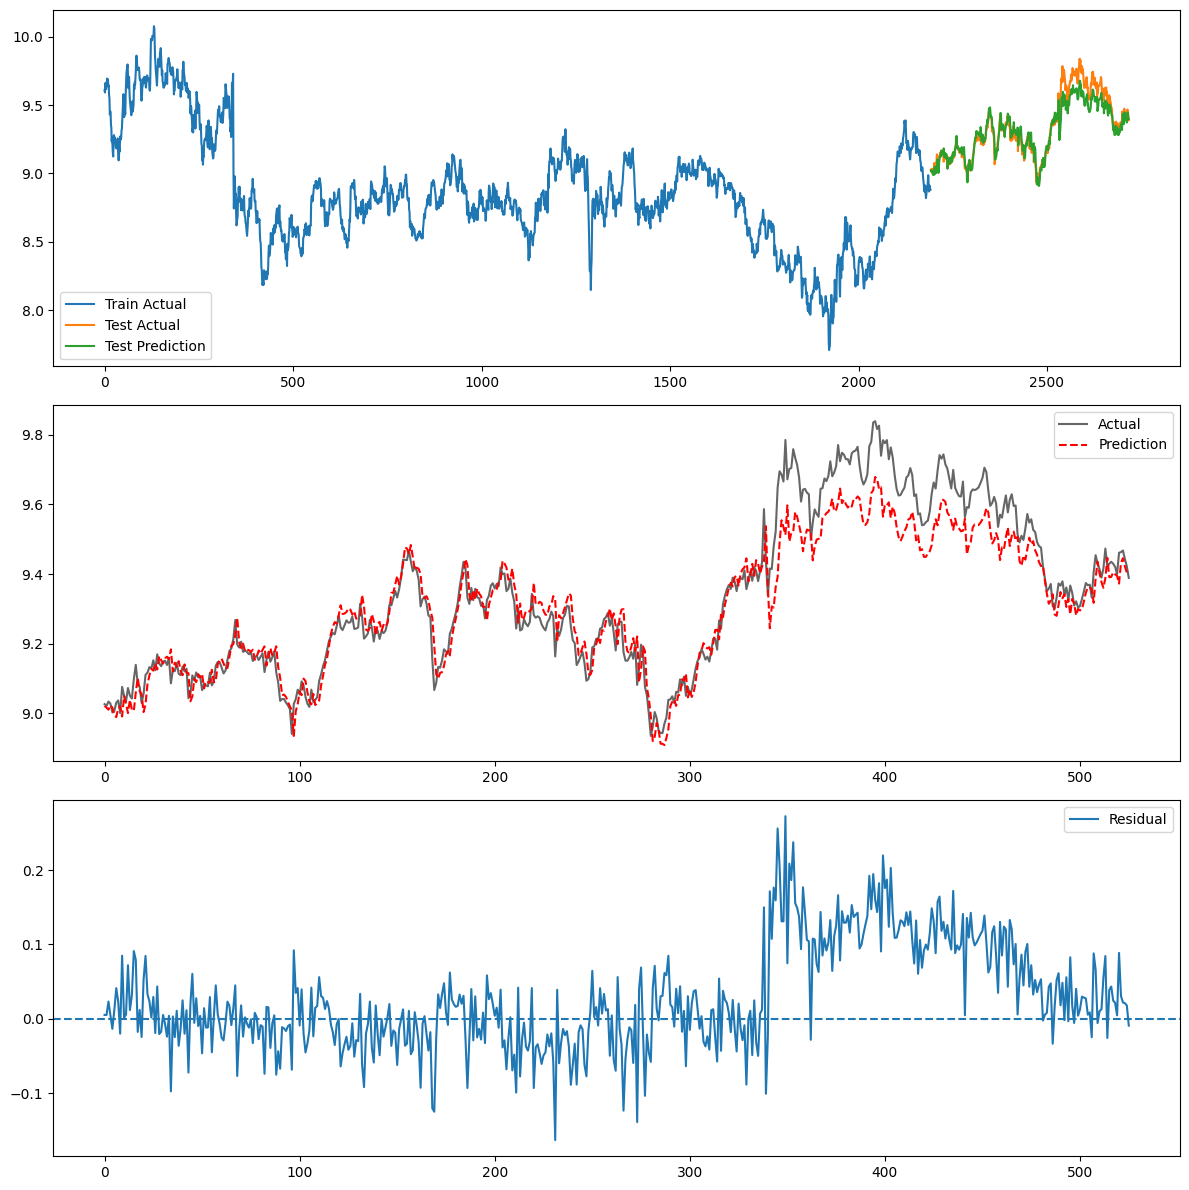

In [ ]:
from fx_forecasting.training.evaluate import evaluate_model
from fx_forecasting.visualization.plots import plot_predictions
from fx_forecasting.data.preprocess import inverse_transform_target


preds, targets, metrics = evaluate_model(
    model,
    val_loader,
    device=device
)

# inverse transform
preds_original = inverse_transform_target(
    preds,
    scaler=scaler,
    columns=feature_columns,
    target_col=TARGET,
)

targets_original = inverse_transform_target(
    targets,
    scaler=scaler,
    columns=feature_columns,
    target_col=TARGET,
)

y_train_original = inverse_transform_target(
    y_train,
    scaler=scaler,
    columns=feature_columns,
    target_col=TARGET,
)

plot_predictions(
    preds=preds_original,
    targets=targets_original,
    train_targets=y_train_original
)